<a href="https://colab.research.google.com/github/navyapalam/fakedocumentdetection/blob/main/fakedocdetection_ipyyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python numpy matplotlib scikit-learn tensorflow pillow

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
os.makedirs("/content/dataset/genuine", exist_ok=True)
os.makedirs("/content/dataset/forged", exist_ok=True)

print("Dataset folders created!")

Dataset folders created!


In [ ]:
from google.colab import files
import shutil

uploaded = files.upload()

for filename in uploaded.keys():
    shutil.move(
        filename,
        "/content/dataset/genuine/" + filename
    )

print("Genuine images uploaded!")

Saving real iamge3.jpg to real iamge3.jpg
Saving real image2.jpg to real image2.jpg
Saving real image1.jpg to real image1.jpg
Genuine images uploaded!


In [ ]:
uploaded = files.upload()

for filename in uploaded.keys():
    shutil.move(
        filename,
        "/content/dataset/forged/" + filename
    )

print("Forged images uploaded!")

Saving fake image2.jpg to fake image2.jpg
Saving fake image3.jpg to fake image3.jpg
Saving fake image1.jpg to fake image1.jpg
Forged images uploaded!


In [ ]:
genuine_files = os.listdir("/content/dataset/genuine")
forged_files = os.listdir("/content/dataset/forged")

print("Number of genuine images:", len(genuine_files))
print("Number of forged images:", len(forged_files))

print("\nGenuine:")
print(genuine_files[:10])

print("\nForged:")
print(forged_files[:10])

Number of genuine images: 3
Number of forged images: 3

Genuine:
['real image2.jpg', 'real image1.jpg', 'real iamge3.jpg']

Forged:
['fake image2.jpg', 'fake image3.jpg', 'fake image1.jpg']


In [ ]:
IMG_SIZE = 128

def load_images(folder, label):

    images = []
    labels = []

    for filename in os.listdir(folder):

        path = os.path.join(folder, filename)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        images.append(img)
        labels.append(label)

    return images, labels

In [ ]:
genuine_images, genuine_labels = load_images(
    "/content/dataset/genuine",
    0
)

forged_images, forged_labels = load_images(
    "/content/dataset/forged",
    1
)

In [ ]:
X = np.array(
    genuine_images + forged_images
)

y = np.array(
    genuine_labels + forged_labels
)

X = X.astype("float32") / 255.0

print("Total images:", len(X))
print("Image shape:", X.shape)
print("Labels shape:", y.shape)

Total images: 6
Image shape: (6, 128, 128, 3)
Labels shape: (6,)


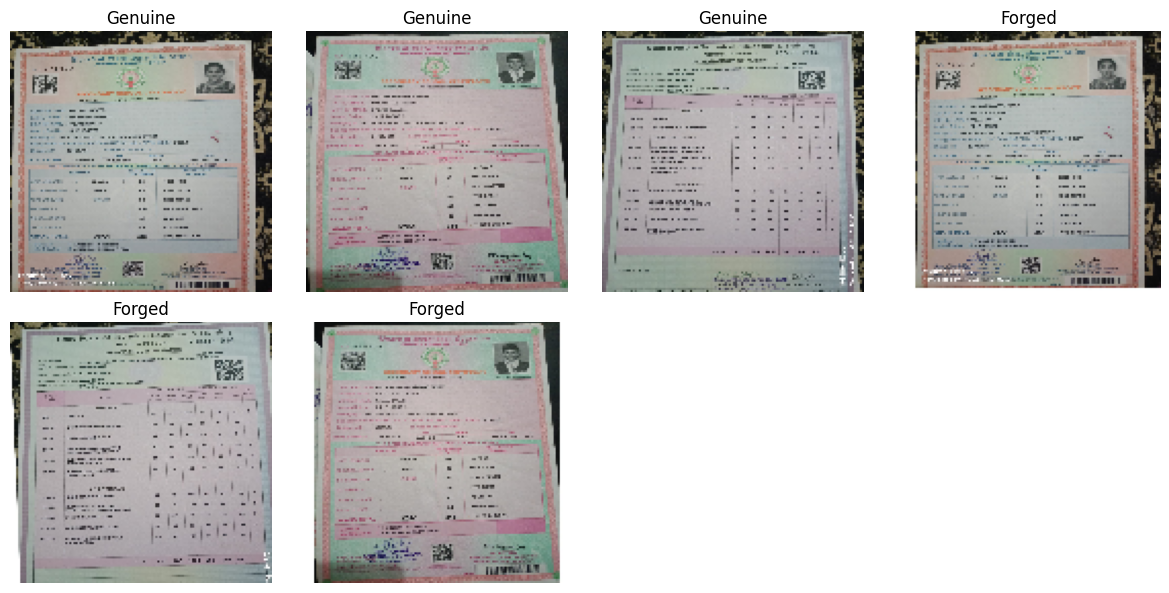

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(min(8, len(X))):

    plt.subplot(2, 4, i + 1)

    plt.imshow(X[i])

    if y[i] == 0:
        plt.title("Genuine")
    else:
        plt.title("Forged")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 4
Testing images: 2


In [ ]:
model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    ),

    MaxPooling2D(2, 2),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(2, 2),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(2, 2),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.6667 - loss: 0.6858 - val_accuracy: 0.0000e+00 - val_loss: 2.4123
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.6667 - loss: 0.8430 - val_accuracy: 0.0000e+00 - val_loss: 2.2624
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step - accuracy: 1.0000 - loss: 0.2117 - val_accuracy: 0.0000e+00 - val_loss: 2.0488
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.6667 - loss: 1.2626 - val_accuracy: 0.0000e+00 - val_loss: 1.0655
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.3333 - loss: 1.4363 - val_accuracy: 1.0000 - val_loss: 0.6904
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6667 - loss: 0.6586 - val_accuracy: 1.0000 - val_loss: 0.6719
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.3333 - loss: 0.7548 - val_accuracy: 0.0000e+00 - val_loss: 0.7499
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.3333 - loss: 0.5869 - val_accuracy: 0

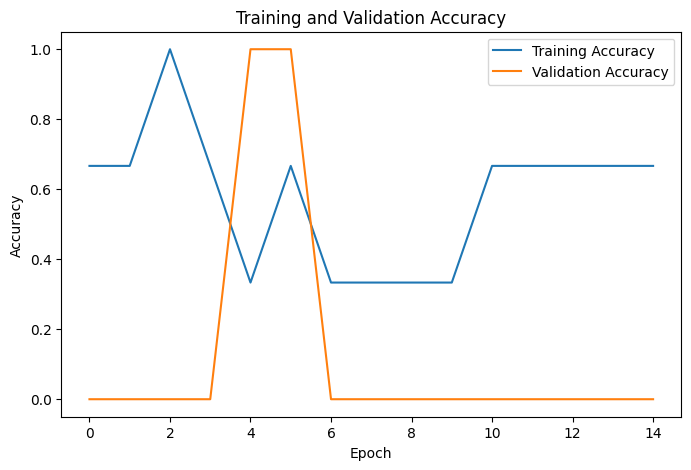

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

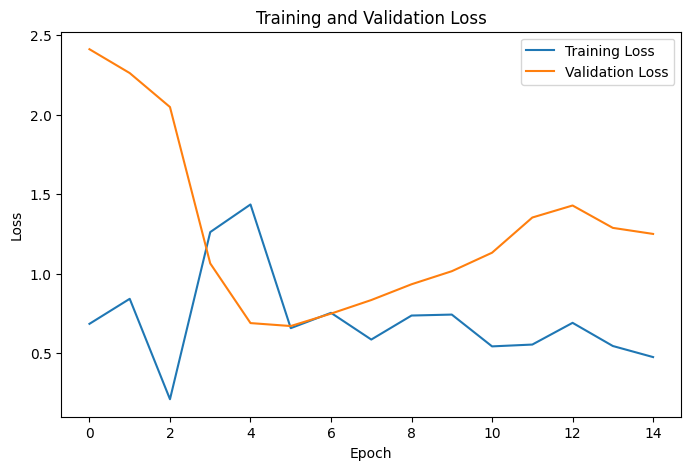

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5000 - loss: 0.8203
Test Accuracy: 50.0 %


In [ ]:
y_probability = model.predict(X_test)

y_pred = (
    y_probability >= 0.5
).astype(int).flatten()

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
Accuracy : 50.0 %
Precision: 0.0 %
Recall   : 0.0 %
F1 Score : 0.0 %


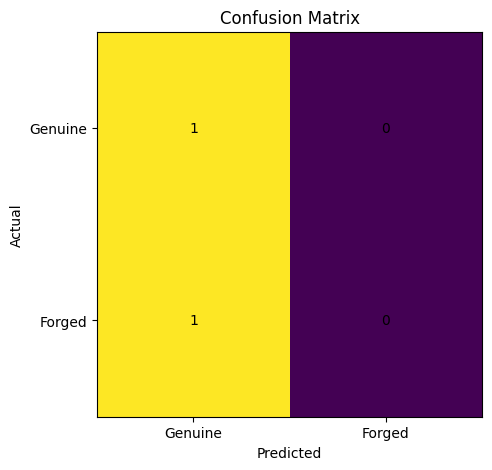

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Genuine", "Forged"]
)

plt.yticks(
    [0, 1],
    ["Genuine", "Forged"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Genuine",
            "Forged"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.50      1.00      0.67         1
      Forged       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



In [ ]:
uploaded = files.upload()

Saving real image3.jpg to real image3.jpg


In [ ]:
filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

img = cv2.resize(
    img,
    (128, 128)
)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img = img.astype("float32") / 255.0

img = np.expand_dims(
    img,
    axis=0
)

prediction = model.predict(img)[0][0]

print("Prediction value:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
Prediction value: 0.2775955


In [23]:
if prediction >= 0.5:

    print("Result: FORGED DOCUMENT")
    print(
        "Confidence:",
        round(prediction * 100, 2),
        "%"
    )

else:

    print("Result: GENUINE DOCUMENT")
    print(
        "Confidence:",
        round((1 - prediction) * 100, 2),
        "%"
    )

Result: GENUINE DOCUMENT
Confidence: 72.24 %


In [24]:
model.save(
    "/content/fake_document_detector.keras"
)

print("Model saved successfully!")

Model saved successfully!
